In [1]:
import os
import glob

from IPython.core.display import HTML

from indra_cogex.analysis.protein_analysis import explain_downstream

source_protein_name = 'CTNNB1'

target_protein_names = ['GLCE','ACSL5','APCDD1','ADAMTSL2','CALML3','CEMIP2','AMOT','PLA2G4A','RCN2','TTC9','FABP4','GPCPD1','VSNL1','CRYBB1','PDZD8','FNDC3A']

output_folder = 'analysis_results'

INFO: [2024-08-19 23:57:49] numexpr.utils - NumExpr defaulting to 8 threads.


INFO: [2024-08-19 23:58:05] indra_cogex.analysis.protein_analysis - Dataframe of protiens that have INDRA relationships with HGNC:2514 that have been filtered:
        name target_type target_id       stmt_type  evidence_count  \
3904   FABP4        HGNC      3559         Complex               1   
3905   FABP4        HGNC      3559      Activation               1   
3906   FABP4        HGNC      3559      Inhibition               1   
3907   FABP4        HGNC      3559  DecreaseAmount               1   
5518    GLCE        HGNC     17855  IncreaseAmount               1   
5519    GLCE        HGNC     17855  IncreaseAmount               2   
5546    AMOT        HGNC     17810         Complex               1   
5547    AMOT        HGNC     17810         Complex               1   
6246  APCDD1        HGNC     15718         Complex               5   
6370  CALML3        HGNC      1452      Activation               1   

              stmt_hash                                          stmt

None


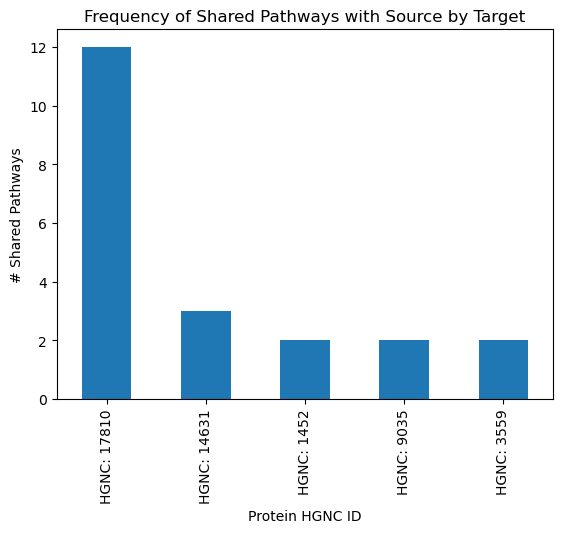

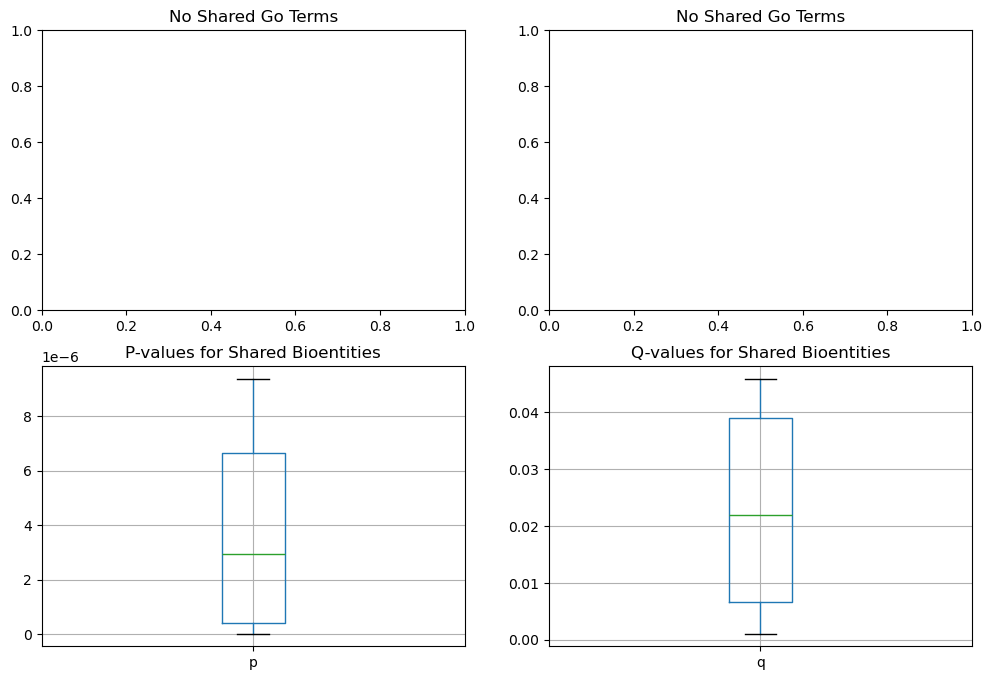

In [2]:
result = explain_downstream(source_protein_name, target_protein_names, output_folder)

In [3]:
import os
from jinja2 import Environment, FileSystemLoader
import webbrowser 

env = Environment(loader=FileSystemLoader('.')) 
template = env.get_template('protein_analysis_template.html')
output = template.render(result=result)

with open('results.html', 'w') as f:
    f.write(output)
webbrowser.open('file://' + os.path.realpath('results.html')) 

True

Look into explaining some upstreams through specific statements

In [3]:
from indra.sources import indra_db_rest
from indra.tools import assemble_corpus as ac
from indra.assemblers.html import HtmlAssembler

In [4]:
ip = indra_db_rest.get_statements(subject='LEF1')
stmts = ac.filter_gene_list(ip.statements, set(target_protein_names) - {'CTNNB1'} | {'LEF1'}, policy='all')
stmts = [s for s in stmts if len({x.name for x in s.real_agent_list()}) > 1]
ha = HtmlAssembler(stmts)
_ = ha.make_model(grouping_level='statement')
ha.save_model(os.path.join(output_folder, 'LEF1_explanations.html'))

INFO: [2024-08-09 16:09:54] indra_db_rest.query_processor - Retrieving statements that have an agent where NAME=LEF1 with role=SUBJECT.
INFO: [2024-08-09 16:09:54] indra_db_rest.request_logs - Running 0th request for statements
INFO: [2024-08-09 16:09:54] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:09:54] indra_db_rest.request_logs -   OFFSET: 0
INFO: [2024-08-09 16:09:55] indra_db_rest.request_logs - Running 1st request for statements
INFO: [2024-08-09 16:09:55] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:09:55] indra_db_rest.request_logs -   OFFSET: 500
INFO: [2024-08-09 16:09:57] indra_db_rest.request_logs - Running 2nd request for statements
INFO: [2024-08-09 16:09:57] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:09:57] indra_db_rest.request_logs -   OFFSET: 1000
INFO: [2024-08-09 16:09:58] indra_db_rest.request_logs - Running 3rd request for statements
INFO: [2024-08-09 16:09:58] indra_db_rest.request_logs -   LIMIT: None


In [5]:
ip = indra_db_rest.get_statements(subject='TCF7L2')
stmts = ac.filter_gene_list(ip.statements, set(target_protein_names) - {'CTNNB1'} | {'TCF7L2'}, policy='all')
stmts = [s for s in stmts if len({x.name for x in s.real_agent_list()}) > 1]
ha = HtmlAssembler(stmts)
_ = ha.make_model(grouping_level='statement')
ha.save_model(os.path.join(output_folder, 'TCF7L2_explanations.html'))

INFO: [2024-08-09 16:10:06] indra_db_rest.query_processor - Retrieving statements that have an agent where NAME=TCF7L2 with role=SUBJECT.
INFO: [2024-08-09 16:10:06] indra_db_rest.request_logs - Running 0th request for statements
INFO: [2024-08-09 16:10:06] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:10:06] indra_db_rest.request_logs -   OFFSET: 0
INFO: [2024-08-09 16:10:07] indra_db_rest.request_logs - Running 1st request for statements
INFO: [2024-08-09 16:10:07] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:10:07] indra_db_rest.request_logs -   OFFSET: 500
INFO: [2024-08-09 16:10:08] indra_db_rest.request_logs - Running 2nd request for statements
INFO: [2024-08-09 16:10:08] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:10:08] indra_db_rest.request_logs -   OFFSET: 1000
INFO: [2024-08-09 16:10:09] indra.tools.assemble_corpus - Filtering 1170 statements for ones containing "all" of: ACSL5, NOTUM, CRYBB1, DKK4, CALML3, CEMIP2, LRP